# Google Play Store EDA


## 1. Data Loading & Inspection

*Loading the dataset and performing initial inspection.*

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/h-almjeiwel/google-play-store-eda/main/data/googleplaystore.csv"
df = pd.read_csv(url)
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df.shape

(10841, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
df.isna().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [6]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


## 2. Data Cleaning & Preprocessing

### 2.1 Standardizing Column Names
*Converting column names to lowercase and replacing spaces with underscores.*

In [7]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['app', 'category', 'rating', 'reviews', 'size', 'installs', 'type',
       'price', 'content_rating', 'genres', 'last_updated', 'current_ver',
       'android_ver'],
      dtype='object')

### 2.2 Preparing Reviews & Handling Duplicates
*Converting 'Reviews' to numeric to ensure accurate sorting, then keeping the version with the highest reviews.*

In [8]:
df.reviews.unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [9]:
df.reviews = df.reviews.str.strip()
df.reviews

,reviews
0,159
1,967
2,87510
3,215644
4,967
...,...
10836,38
10837,4
10838,3
10839,114


In [10]:
df.reviews = pd.to_numeric(df.reviews, errors='coerce')
df.reviews

,reviews
0,159.0
1,967.0
2,87510.0
3,215644.0
4,967.0
...,...
10836,38.0
10837,4.0
10838,3.0
10839,114.0


In [11]:
df.app.duplicated().sum()

np.int64(1181)

In [12]:
df = df.sort_values('reviews', ascending=False)

df = df.drop_duplicates(subset=['app'], keep='first').reset_index(drop=True)

In [13]:
df.app.duplicated().sum()

np.int64(0)

### 2.3 Removing Data Entry Errors

In [14]:
df.category.unique()

array(['SOCIAL', 'COMMUNICATION', 'GAME', 'TOOLS', 'VIDEO_PLAYERS',
       'NEWS_AND_MAGAZINES', 'PHOTOGRAPHY', 'FAMILY', 'TRAVEL_AND_LOCAL',
       'PERSONALIZATION', 'MAPS_AND_NAVIGATION', 'SHOPPING',
       'ENTERTAINMENT', 'PRODUCTIVITY', 'HEALTH_AND_FITNESS', 'SPORTS',
       'BOOKS_AND_REFERENCE', 'LIFESTYLE', 'WEATHER', 'FINANCE',
       'BUSINESS', 'EDUCATION', 'FOOD_AND_DRINK', 'COMICS', 'PARENTING',
       'DATING', 'HOUSE_AND_HOME', 'LIBRARIES_AND_DEMO', 'ART_AND_DESIGN',
       'AUTO_AND_VEHICLES', 'MEDICAL', 'BEAUTY', 'EVENTS', '1.9'],
      dtype=object)

In [15]:
df[df.category == '1.9']

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
9659,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,NaN,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [16]:
#Remove the row where category is '1.9' This is a known data entry error in the dataset.
df.drop(index=9659, inplace=True)

In [17]:
df.category.unique()

array(['SOCIAL', 'COMMUNICATION', 'GAME', 'TOOLS', 'VIDEO_PLAYERS',
       'NEWS_AND_MAGAZINES', 'PHOTOGRAPHY', 'FAMILY', 'TRAVEL_AND_LOCAL',
       'PERSONALIZATION', 'MAPS_AND_NAVIGATION', 'SHOPPING',
       'ENTERTAINMENT', 'PRODUCTIVITY', 'HEALTH_AND_FITNESS', 'SPORTS',
       'BOOKS_AND_REFERENCE', 'LIFESTYLE', 'WEATHER', 'FINANCE',
       'BUSINESS', 'EDUCATION', 'FOOD_AND_DRINK', 'COMICS', 'PARENTING',
       'DATING', 'HOUSE_AND_HOME', 'LIBRARIES_AND_DEMO', 'ART_AND_DESIGN',
       'AUTO_AND_VEHICLES', 'MEDICAL', 'BEAUTY', 'EVENTS'], dtype=object)

### 2.4 Handling Missing Values

* **2.4.1** Null Values Exploration

In [18]:
df.isna().sum()

,0
app,0
category,0
rating,1463
reviews,0
size,0
installs,0
type,1
price,0
content_rating,0
genres,0


* **2.4.2 Rating Column:** Dropping rows with missing ratings to ensure analytical integrity.

In [19]:
df.rating.unique()

array([4.1, 4.4, 4.5, 4. , 4.6, 4.7, 4.3, 4.2, 3.8, 4.8, 3.7, 3.9, 4.9,
       3.3, 3.6, 3.5, 3.4, 2.8, 3.2, 3.1, 3. , 2.9, 2.4, 2.7, 2.5, 1.8,
       nan, 2.1, 2. , 1.7, 1.9, 2.2, 2.3, 2.6, 1.6, 5. , 1.5, 1.4, 1.2,
       1. ])

In [20]:
df.rating.isna().sum()

np.int64(1463)

In [21]:
df = df.dropna(subset=['rating']).reset_index(drop=True)

In [22]:
df.shape

(8196, 13)

* **2.4.3** Final Verification

In [23]:
df.isna().sum()

,0
app,0
category,0
rating,0
reviews,0
size,0
installs,0
type,0
price,0
content_rating,0
genres,0


### 2.5 Data Cleaning & Transformation
*Cleaning special characters and transforming columns into appropriate formats for analysis.*




* **2.5.1 Installs column:** Stripping '+' and ',' and converting to integer.

In [24]:
df.installs.unique()

array(['1,000,000,000+', '100,000,000+', '500,000,000+', '50,000,000+',
       '10,000,000+', '5,000,000+', '1,000,000+', '500,000+', '100,000+',
       '50,000+', '10,000+', '5,000+', '1,000+', '500+', '100+', '10+',
       '50+', '5+', '1+'], dtype=object)

In [25]:
#Clean the 'installs' column by removing special characters in one flow
df.installs = df.installs.str.replace('+', '').str.replace(',', '')
df.installs

,installs
0,1000000000
1,1000000000
2,1000000000
3,1000000000
4,100000000
...,...
8191,10
8192,100
8193,10
8194,500


In [26]:
df.installs = pd.to_numeric(df.installs, errors='coerce')
df.installs

,installs
0,1000000000
1,1000000000
2,1000000000
3,1000000000
4,100000000
...,...
8191,10
8192,100
8193,10
8194,500


* **2.5.2 Price column:** Removing '$' and converting to float.

In [27]:
df.price.unique()

array(['0', '$6.99', '$0.99', '$2.99', '$1.99', '$2.49', '$4.99', '$5.99',
       '$4.49', '$9.99', '$3.99', '$1.49', '$3.95', '$7.99', '$3.49',
       '$8.99', '$13.99', '$19.99', '$11.99', '$12.99', '$2.90', '$17.99',
       '$399.99', '$29.99', '$14.99', '$2.95', '$4.77', '$24.99', '$3.90',
       '$2.50', '$3.28', '$1.20', '$2.59', '$9.00', '$1.59', '$1.00',
       '$5.49', '$18.99', '$299.99', '$1.97', '$400.00', '$16.99',
       '$389.99', '$33.99', '$10.00', '$10.99', '$4.84', '$37.99',
       '$1.61', '$4.60', '$79.99', '$4.29', '$1.70', '$1.50', '$1.29',
       '$19.40', '$3.08', '$379.99', '$8.49', '$2.56', '$15.46', '$7.49',
       '$4.59', '$2.00', '$14.00', '$6.49', '$15.99', '$3.88', '$3.02',
       '$39.99', '$1.75', '$1.76', '$3.04'], dtype=object)

In [28]:
df.price = df.price.str.replace('$', '')
df.price

,price
0,0
1,0
2,0
3,0
4,0
...,...
8191,2.99
8192,4.99
8193,0
8194,0


In [29]:
df.price = pd.to_numeric(df.price, errors='coerce')
df.price

,price
0,0.00
1,0.00
2,0.00
3,0.00
4,0.00
...,...
8191,2.99
8192,4.99
8193,0.00
8194,0.00


* **2.5.3 last_updated column**: converting to datetime

In [30]:
df.last_updated.unique()

array(['August 3, 2018', 'July 31, 2018', 'August 1, 2018', ...,
       'April 20, 2017', 'April 9, 2012', 'August 31, 2013'], dtype=object)

In [31]:
df.last_updated.sample(5)

,last_updated
1688,"July 31, 2018"
2435,"July 11, 2018"
6836,"July 7, 2017"
1024,"June 1, 2018"
7670,"June 28, 2018"


In [32]:
df.last_updated = pd.to_datetime(df.last_updated, errors='coerce')
df.last_updated

,last_updated
0,2018-08-03
1,2018-08-03
2,2018-07-31
3,2018-08-01
4,2018-07-15
...,...
8191,2016-10-07
8192,2018-03-28
8193,2018-02-16
8194,2018-07-19


In [33]:
df.describe()

,rating,reviews,installs,price,last_updated
count,8196.000000,8.196000e+03,8.196000e+03,8196.000000,8196
mean,4.173267,2.555008e+05,9.189442e+06,1.035447,2017-11-05 10:31:26.969253120
min,1.000000,1.000000e+00,1.000000e+00,0.000000,2010-05-21 00:00:00
25%,4.000000,1.270000e+02,1.000000e+04,0.000000,2017-08-17 00:00:00
50%,4.300000,3.017000e+03,1.000000e+05,0.000000,2018-05-20 00:00:00
75%,4.500000,4.397675e+04,1.000000e+06,0.000000,2018-07-19 00:00:00
max,5.000000,7.815831e+07,1.000000e+09,400.000000,2018-08-08 00:00:00
std,0.536253,1.985709e+06,5.826274e+07,16.857244,NaN


## 3. Data Visualization & Analysis

### 3.1 Category Popularity based on Installs (Top 10)

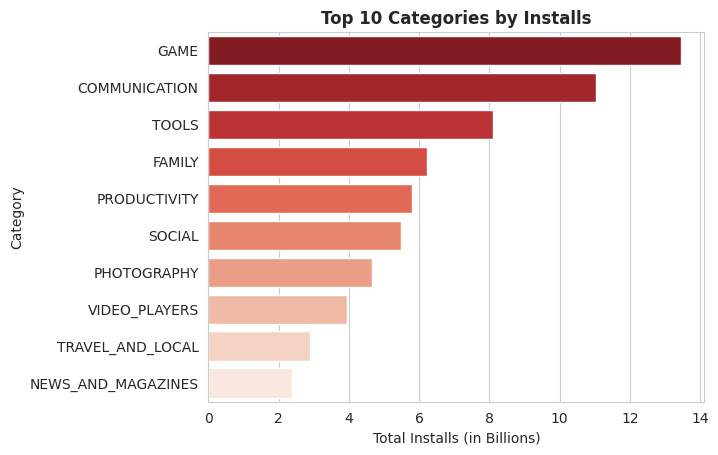

In [34]:
category_installs= df.groupby('category')['installs'].sum().sort_values(ascending=False).reset_index().head(10)
x_data = category_installs['installs'] / 1e9
sns.set_style('whitegrid')
a=sns.barplot(data=category_installs, x= x_data , y='category', hue='category', palette='Reds_r')
a.set_title('Top 10 Categories by Installs',fontweight='bold')
a.set(xlabel= ('Total Installs (in Billions)'), ylabel= 'Category')

plt.show()

### 3.2 Number of Apps per Category

/tmp/ipykernel_1347/3353398364.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  b=a=sns.barplot(data=category_apps, x= 'app' , y='category', palette='Blues_r')


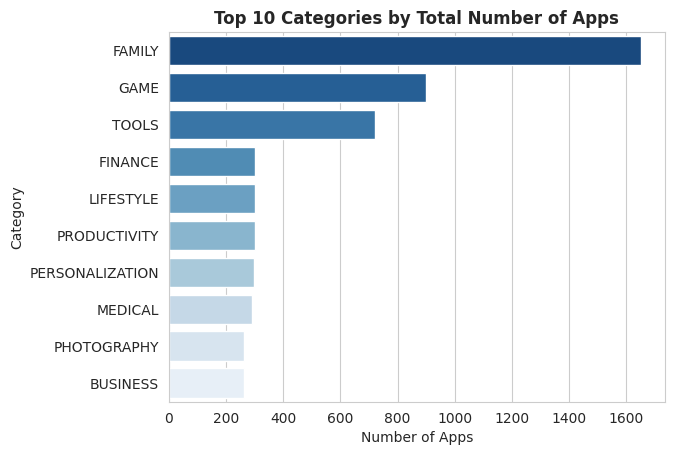

In [35]:
category_apps= df.groupby('category')['app'].count().sort_values(ascending=False).reset_index().head(10)
b=a=sns.barplot(data=category_apps, x= 'app' , y='category', palette='Blues_r')
b.set_title('Top 10 Categories by Total Number of Apps',fontweight='bold')
b.set(xlabel= ('Number of Apps'), ylabel= 'Category')
plt.show()

### 3.3 App Type Distribution by Category



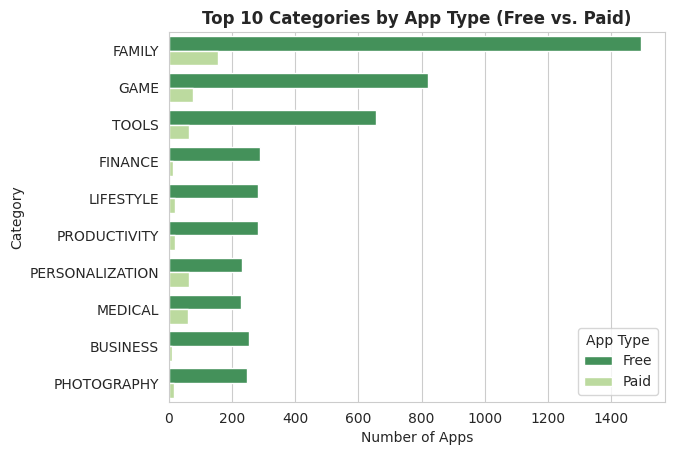

In [36]:
top_10_categories = df['category'].value_counts().head(10).index
top10=df[df['category'].isin(top_10_categories)]
c=sns.countplot(data=top10, y='category', hue='type', palette='YlGn_r', order=top_10_categories)
c.legend(title='App Type')
c.set_title('Top 10 Categories by App Type (Free vs. Paid)',fontweight='bold')
c.set(xlabel= 'Number of Apps', ylabel= 'Category')
plt.show()

### 3.4 Low vs. High Price Distribution
*The data is split into two charts to better visualize the majority of apps (Low Price) vs.(High Price)*

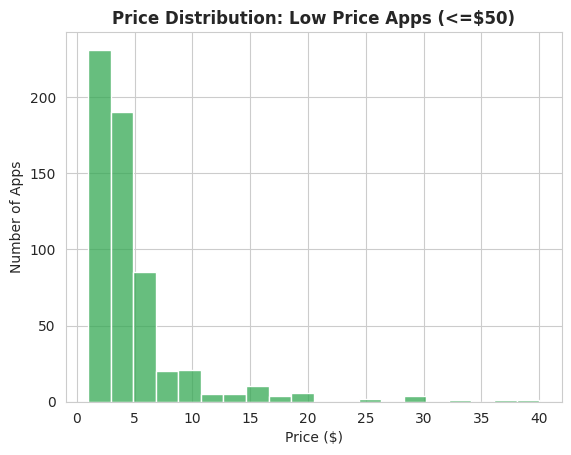

In [37]:
low_price_apps = df[(df['type'] == 'Paid') & (df['price'] <= 50)]
d=sns.histplot(low_price_apps['price'], bins=20, color='#34A853')
d.set_title('Price Distribution: Low Price Apps (<=$50)', fontweight='bold')
d.set(xlabel= 'Price ($)', ylabel= 'Number of Apps')
plt.show()

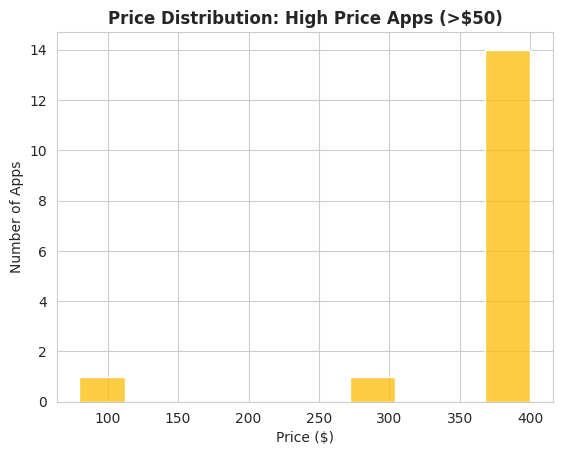

In [38]:
high_price_apps = df[(df['type'] == 'Paid') & (df['price'] > 50)]
e=sns.histplot(high_price_apps['price'], bins=10, color='#FBBC05')
e.set_title('Price Distribution: High Price Apps (>$50)', fontweight='bold')
e.set(xlabel= 'Price ($)', ylabel= 'Number of Apps')
plt.show()